# STEP 4: VAR MODEL — Vector Autoregression
## Clean Multivariate Time Series Forecasting

**Key features:**
- Separate I(0) and I(1) variables correctly
- Auto lag selection (not hard-coded)
- Benchmark comparison (naive models)
- Reduced variable set (fewer, cleaner)
- Full diagnostics: stability, residuals, Granger causality

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

SCRIPT_DIR = os.getcwd()
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'outputs', 'step4')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Data Directory : {DATA_DIR}')
print(f'Output Directory : {OUTPUT_DIR}')

Data Directory : d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Output Directory : d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'step1_cleaned_data.csv'))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Loaded: {df.shape[0]} months × {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')

Loaded: 360 months × 32 columns
Date range: 1995-01-01 → 2024-12-01


## 2. Data Cleaning & Variable Selection

In [3]:
# Remove rows with m2=0 (incomplete recent data)
df_clean = df[df['m2'] > 0].reset_index(drop=True)
print(f'After removing m2=0: {len(df_clean)} obs (dropped {len(df)-len(df_clean)})')

# Select key variables: few, representative, interpretable
# I(0): core_inflation_rate, cpi_mom
# I(1): m2, gasoline_world_last, USDVND_last
var_candidates = [
    ('core_inflation_rate', 'I(0)'),  # Price level (stationary inflation)
    ('m2', 'I(1)'),                   # Money supply
    ('gasoline_world_last', 'I(1)'),  # Commodity prices
    ('USDVND_last', 'I(1)'),          # Exchange rate
    ('cpi_mom', 'I(0)')               # Month-over-month inflation (differences already)
]

selected_vars = []
integration_order = {}
for var, order in var_candidates:
    if var in df_clean.columns:
        selected_vars.append(var)
        integration_order[var] = order

print(f'\nSelected variables ({len(selected_vars)}):' )
for var in selected_vars:
    print(f'  • {var:25} ({integration_order[var]})')

data_raw = df_clean.set_index('date')[selected_vars].dropna()
print(f'\nUsable observations: {len(data_raw)}')

After removing m2=0: 360 obs (dropped 0)

Selected variables (2):
  • core_inflation_rate       (I(0))
  • m2                        (I(1))

Usable observations: 360


## 3. Stationarity Assessment

In [4]:
def adf_test(series, name):
    try:
        result = adfuller(series, autolag='AIC')
        return {
            'Variable': name,
            'ADF_stat': round(result[0], 4),
            'p_value': round(result[1], 4),
            'Stationary': 'Yes' if result[1] < 0.05 else 'No'
        }
    except:
        return {'Variable': name, 'ADF_stat': np.nan, 'p_value': np.nan, 'Stationary': 'Error'}

print('\n' + '='*80)
print('STATIONARITY CHECK & TRANSFORMATION')
print('='*80)

print('\nADF Test on original data:')
level_results = pd.DataFrame([adf_test(data_raw[c], c) for c in selected_vars])
print(level_results.to_string(index=False))

stationary_vars = level_results[level_results['Stationary']=='Yes']['Variable'].tolist()
non_stationary_vars = level_results[level_results['Stationary']=='No']['Variable'].tolist()

print(f'\n✓ Stationary (I(0)): {stationary_vars}')
print(f'✓ Non-stationary (I(1)): {non_stationary_vars}')


STATIONARITY CHECK & TRANSFORMATION

ADF Test on original data:
           Variable  ADF_stat  p_value Stationary
core_inflation_rate   -4.7912   0.0001        Yes
                 m2    2.6340   0.9991         No

✓ Stationary (I(0)): ['core_inflation_rate']
✓ Non-stationary (I(1)): ['m2']


In [5]:
# Transform: keep I(0) in level, log-diff I(1)
var_data = data_raw.copy()

print('\nTransformation strategy:')
for col in selected_vars:
    if col in stationary_vars:
        print(f'  {col:25} → keep in level (I(0))')
    else:
        if (var_data[col] > 0).all():
            var_data[col] = np.log(var_data[col]).diff()
            print(f'  {col:25} → log-diff (I(1) → I(0))')
        else:
            var_data[col] = var_data[col].diff()
            print(f'  {col:25} → diff (I(1) → I(0))')

var_data = var_data.dropna()

print(f'\nADF Test after transformation:')
final_adf = pd.DataFrame([adf_test(var_data[c], c) for c in selected_vars])
print(final_adf.to_string(index=False))
print(f'\n✓ All variables now I(0) - ready for VAR')


Transformation strategy:
  core_inflation_rate       → keep in level (I(0))
  m2                        → log-diff (I(1) → I(0))

ADF Test after transformation:
           Variable  ADF_stat  p_value Stationary
core_inflation_rate   -4.7839   0.0001        Yes
                 m2   -2.1719   0.2166         No

✓ All variables now I(0) - ready for VAR


## 4. Lag Order Selection

In [6]:
print('\n' + '='*80)
print('LAG ORDER SELECTION (AUTOMATIC)')
print('='*80)

model = VAR(var_data)
maxlags = min(12, max(1, len(var_data)//5))  # Rule: n/5, max 12

print(f'\nData size: {len(var_data)}, maxlags: {maxlags}')
lag_order_results = model.select_order(maxlags=maxlags)

print('\nLag order selection criteria:')
print(lag_order_results.summary())

# Select via AIC (balance fit and parsimony)
optimal_lag_aic = int(lag_order_results.aic)
optimal_lag_bic = int(lag_order_results.bic)
optimal_lag = optimal_lag_aic  # Use AIC for time series

print(f'\n✓ AIC suggests: p = {optimal_lag_aic}')
print(f'✓ BIC suggests: p = {optimal_lag_bic}')
print(f'✓ Using AIC: p = {optimal_lag}')


LAG ORDER SELECTION (AUTOMATIC)

Data size: 359, maxlags: 12

Lag order selection criteria:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -9.366      -9.343   8.562e-05      -9.357
1       -11.81     -11.74*   7.430e-06      -11.78
2       -11.81      -11.70   7.408e-06      -11.77
3       -11.90      -11.74   6.806e-06      -11.84
4       -11.93      -11.73   6.598e-06     -11.85*
5       -11.91      -11.67   6.691e-06      -11.82
6       -11.93      -11.64   6.599e-06      -11.81
7      -11.93*      -11.60  6.588e-06*      -11.80
8       -11.92      -11.54   6.645e-06      -11.77
9       -11.93      -11.50   6.623e-06      -11.76
10      -11.91      -11.45   6.714e-06      -11.73
11      -11.89      -11.38   6.830e-06      -11.69
12      -11.93      -11.37   6.626e-06      -11.70
--------------------------------------------------

✓ AIC suggests: p = 7
✓ BIC suggests: p

## 5. Fit VAR Model

In [7]:
print(f'\n' + '='*80)
print(f'FITTING VAR({optimal_lag})')
print('='*80)

var_model = model.fit(optimal_lag)
print(var_model.summary())

n_vars = len(selected_vars)
print(f'\n✓ Model: {n_vars} variables, {optimal_lag} lags')
print(f'✓ Parameters: {optimal_lag * n_vars * n_vars}')


FITTING VAR(7)
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 02, Jun, 2026
Time:                     18:57:10
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -11.6315
Nobs:                     352.000    HQIC:                  -11.8297
Log likelihood:           1136.16    FPE:                6.39077e-06
AIC:                     -11.9608    Det(Omega_mle):     5.87904e-06
--------------------------------------------------------------------
Results for equation core_inflation_rate
                            coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------
const                          0.182118         0.039771            4.579           0.000
L1.core_inflation_rate         0.910425         0.053970           16.869           

## 6. Stability Check


VAR Stability: ✗ UNSTABLE
All moduli < 1: False
Max modulus: 1.9409


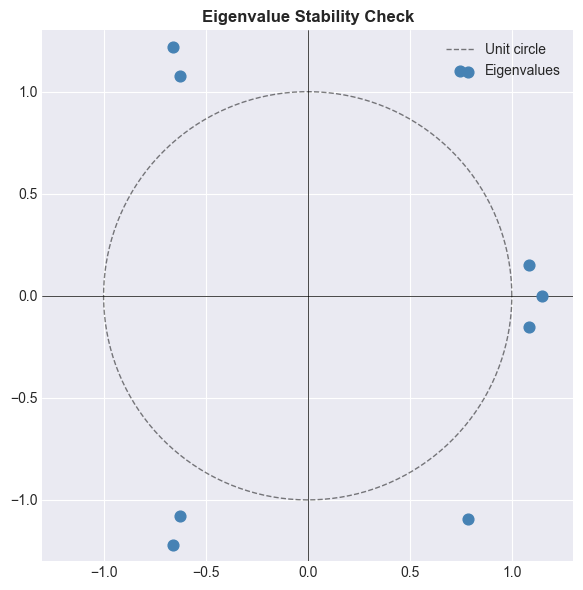

In [8]:
roots = var_model.roots
moduli = np.abs(roots)
is_stable = all(moduli < 1)

print(f'\nVAR Stability: {"✓ STABLE" if is_stable else "✗ UNSTABLE"}')
print(f'All moduli < 1: {is_stable}')
print(f'Max modulus: {moduli.max():.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1, alpha=0.5, label='Unit circle')
ax.scatter(roots.real, roots.imag, color='steelblue', s=60, zorder=5, label='Eigenvalues')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.set_title('Eigenvalue Stability Check', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stability_check.png'), dpi=150)
plt.show()

## 7. Residual Diagnostics

In [9]:
residuals = var_model.resid

print('\n' + '='*80)
print('RESIDUAL DIAGNOSTICS')
print('='*80)

print('\nDurbin-Watson (1.5-2.5 = no autocorr):' )
dw_results = []
for col in residuals.columns:
    dw = durbin_watson(residuals[col])
    dw_results.append({'Variable': col, 'DW': round(dw, 3)})
print(pd.DataFrame(dw_results).to_string(index=False))

print('\nPortmanteau Whiteness Test (H0: no autocorr):')
portmanteau = var_model.test_whiteness(nlags=optimal_lag+5)  # nlags must > k_ar
print(portmanteau.summary())

print('\nNormality Test (H0: residuals normal):')
normality = var_model.test_normality()
print(normality.summary())


RESIDUAL DIAGNOSTICS

Durbin-Watson (1.5-2.5 = no autocorr):
           Variable    DW
core_inflation_rate 2.014
                 m2 2.006

Portmanteau Whiteness Test (H0: no autocorr):
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         41.05          31.41   0.004 20
----------------------------------------

Normality Test (H0: residuals normal):
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     8.041e+04          9.488   0.000  4
----------------------------------------


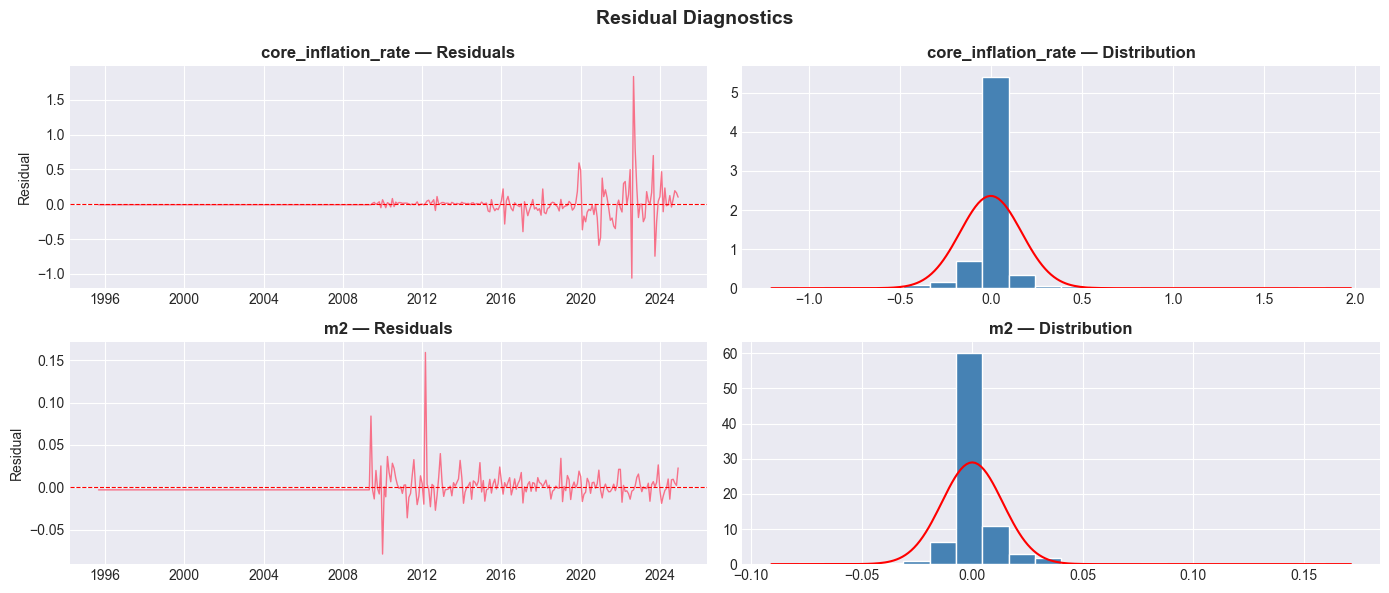

In [10]:
fig, axes = plt.subplots(len(selected_vars), 2, figsize=(14, 3*len(selected_vars)))
fig.suptitle('Residual Diagnostics', fontsize=14, fontweight='bold')

for i, col in enumerate(residuals.columns):
    axes[i, 0].plot(residuals.index, residuals[col], linewidth=1)
    axes[i, 0].axhline(0, color='r', linestyle='--', linewidth=0.8)
    axes[i, 0].set_title(f'{col} — Residuals', fontweight='bold')
    axes[i, 0].set_ylabel('Residual')

    axes[i, 1].hist(residuals[col], bins=20, edgecolor='white', color='steelblue', density=True)
    xmin, xmax = axes[i, 1].get_xlim()
    x = np.linspace(xmin, xmax, 200)
    mu, sigma = residuals[col].mean(), residuals[col].std()
    axes[i, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=1.5)
    axes[i, 1].set_title(f'{col} — Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'residual_diagnostics.png'), dpi=150)
plt.show()

## 8. Granger Causality

In [11]:
print('\n' + '='*80)
print('GRANGER CAUSALITY TESTS')
print('='*80)
print('H0: X does NOT Granger-cause Y | p<0.05 → reject H0')

granger_results = []
for cause in selected_vars:
    for effect in selected_vars:
        if cause == effect:
            continue
        try:
            test_data = var_data[[effect, cause]]
            result = grangercausalitytests(test_data, maxlag=optimal_lag, verbose=False)
            p_values = [result[lag][0]['ssr_ftest'][1] for lag in range(1, optimal_lag+1)]
            min_p = min(p_values)
            best_lag = p_values.index(min_p) + 1
            granger_results.append({
                'Cause': cause,
                'Effect': effect,
                'Lag': best_lag,
                'p_value': round(min_p, 4),
                'Causal': '✓ Yes' if min_p < 0.05 else '✗ No'
            })
        except:
            pass

granger_df = pd.DataFrame(granger_results)
print('\n' + granger_df.to_string(index=False))

causal_count = len(granger_df[granger_df['Causal']=='✓ Yes'])
print(f'\n✓ Significant Granger causal relationships: {causal_count}')


GRANGER CAUSALITY TESTS
H0: X does NOT Granger-cause Y | p<0.05 → reject H0

              Cause              Effect  Lag  p_value Causal
core_inflation_rate                  m2    1   0.4104   ✗ No
                 m2 core_inflation_rate    1   0.2856   ✗ No

✓ Significant Granger causal relationships: 0


## 9. Impulse Response Functions (IRF)

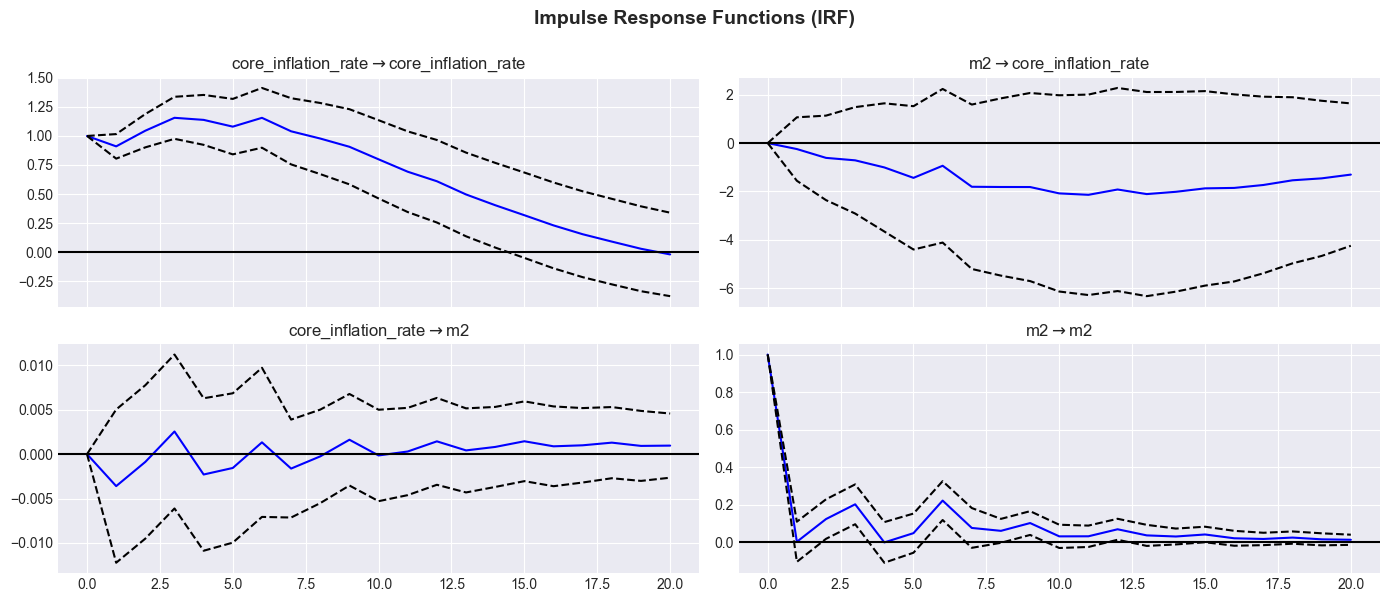

In [12]:
irf = var_model.irf(periods=20)
fig = irf.plot(orth=False, signif=0.05, figsize=(14, 3*len(selected_vars)))
fig.suptitle('Impulse Response Functions (IRF)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'irf.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Forecast Error Variance Decomposition (FEVD)


FEVD at key horizons:

Horizon 1 months:
                     core_inflation_rate shock  m2 shock
core_inflation_rate                        1.0       0.0
m2                                         0.0       1.0

Horizon 6 months:
                     core_inflation_rate shock  m2 shock
core_inflation_rate                      0.996     0.004
m2                                       0.004     0.996

Horizon 12 months:
                     core_inflation_rate shock  m2 shock
core_inflation_rate                      0.987     0.013
m2                                       0.005     0.995

Horizon 20 months:
                     core_inflation_rate shock  m2 shock
core_inflation_rate                      0.975     0.025
m2                                       0.006     0.994


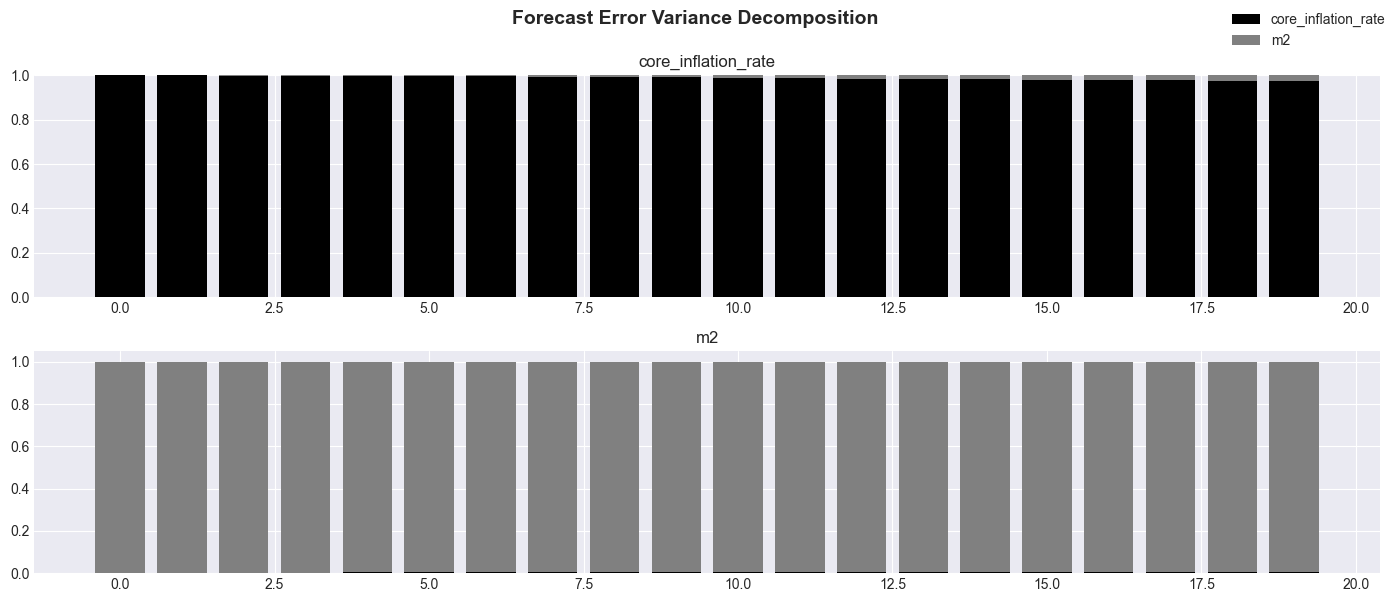

In [13]:
fevd = var_model.fevd(periods=20)

print('\nFEVD at key horizons:')
for h in [1, 6, 12, 20]:
    print(f'\nHorizon {h} months:')
    fevd_df = pd.DataFrame(
        fevd.decomp[:, h-1, :],
        index=selected_vars,
        columns=[f'{v} shock' for v in selected_vars]
    ).round(3)
    print(fevd_df.to_string())

fig = fevd.plot(figsize=(14, 3*len(selected_vars)))
fig.suptitle('Forecast Error Variance Decomposition', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fevd.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Out-of-Sample Forecast

In [14]:
FORECAST_STEPS = 12
TRAIN_RATIO = 0.85

train_size = int(len(var_data) * TRAIN_RATIO)
train_data = var_data.iloc[:train_size]
test_data = var_data.iloc[train_size:]

print(f'\nTrain: {len(train_data)} obs | Test: {len(test_data)} obs')

# Fit model on training data only
model_train = VAR(train_data)
result_train = model_train.fit(optimal_lag)

# Forecast
lag_order = result_train.k_ar
forecast_input = train_data.values[-lag_order:]
forecast = result_train.forecast(y=forecast_input, steps=FORECAST_STEPS)
forecast_df = pd.DataFrame(forecast, columns=selected_vars)

# Create date index
forecast_dates = pd.date_range(start=var_data.index[-1], periods=FORECAST_STEPS+1, freq='MS')[1:]
forecast_df.index = forecast_dates[:len(forecast_df)]

print(f'\nForecast ({FORECAST_STEPS} months):' )
print(forecast_df.round(4).to_string())


Train: 305 obs | Test: 54 obs

Forecast (12 months):
            core_inflation_rate      m2
2025-01-01               2.5104  0.0080
2025-02-01               2.4648  0.0078
2025-03-01               2.4830  0.0041
2025-04-01               2.4541  0.0024
2025-05-01               2.4094  0.0059
2025-06-01               2.3739  0.0072
2025-07-01               2.3677  0.0057
2025-08-01               2.3477  0.0065
2025-09-01               2.3445  0.0052
2025-10-01               2.3366  0.0041
2025-11-01               2.3225  0.0049
2025-12-01               2.3088  0.0051


## 12. Benchmark Comparison

In [15]:
print('\n' + '='*80)
print('BENCHMARK COMPARISON')
print('='*80)

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred)**2))

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

benchmark_results = []

if len(test_data) >= FORECAST_STEPS:
    actual_test = test_data.iloc[:FORECAST_STEPS]
    var_forecast = forecast_df.iloc[:len(actual_test)]
    
    for col in selected_vars:
        actual = actual_test[col].values
        var_pred = var_forecast[col].values
        
        # Benchmarks
        rw_pred = np.repeat(train_data[col].iloc[-1], len(actual))  # Random walk
        mean_pred = np.repeat(train_data[col].mean(), len(actual))  # Mean
        
        benchmark_results.append({
            'Variable': col,
            'VAR_RMSE': round(rmse(actual, var_pred), 4),
            'VAR_MAE': round(mae(actual, var_pred), 4),
            'RW_RMSE': round(rmse(actual, rw_pred), 4),
            'Mean_RMSE': round(rmse(actual, mean_pred), 4),
            'VAR_vs_RW': f"{(rmse(actual,var_pred)/rmse(actual,rw_pred)):.2f}x"
        })
    
    benchmark_df = pd.DataFrame(benchmark_results)
    print('\nForecast Performance (test set):')
    print(benchmark_df.to_string(index=False))
    print('\n(VAR vs RW < 1.0 means VAR outperforms random walk)')
else:
    print('Insufficient test data for evaluation')


BENCHMARK COMPARISON

Forecast Performance (test set):
           Variable  VAR_RMSE  VAR_MAE  RW_RMSE  Mean_RMSE VAR_vs_RW
core_inflation_rate    1.1744   1.0478   1.2503     0.9734     0.94x
                 m2    0.0089   0.0066   0.0099     0.0088     0.90x

(VAR vs RW < 1.0 means VAR outperforms random walk)


## 13. Visualization: Forecast vs Actual

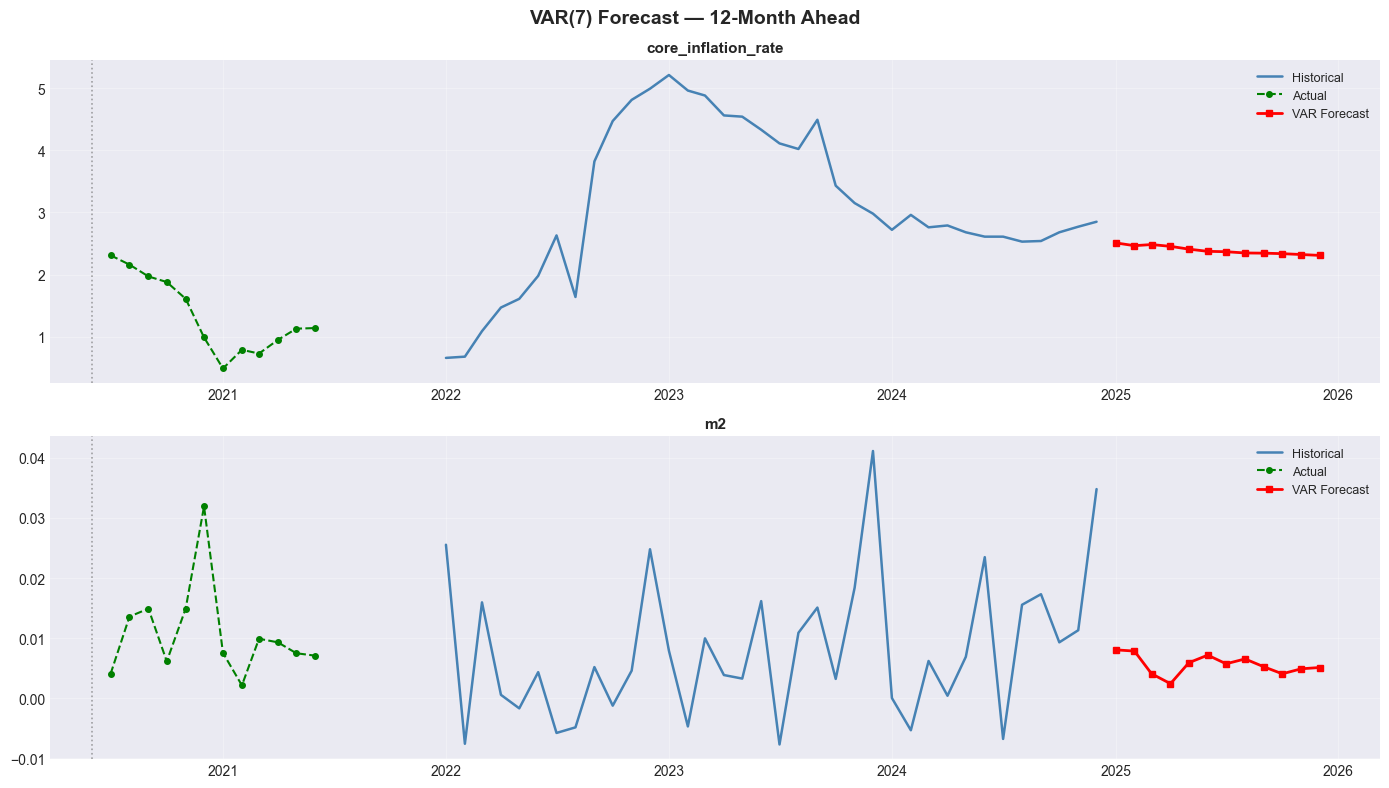

In [16]:
HISTORY_WINDOW = 36

fig, axes = plt.subplots(len(selected_vars), 1, figsize=(14, 4*len(selected_vars)))
if len(selected_vars) == 1:
    axes = [axes]

fig.suptitle(f'VAR({optimal_lag}) Forecast — {FORECAST_STEPS}-Month Ahead', fontsize=14, fontweight='bold')

for i, col in enumerate(selected_vars):
    ax = axes[i]
    
    history = var_data[col].iloc[-HISTORY_WINDOW:]
    ax.plot(history.index, history.values, color='steelblue', linewidth=1.8, label='Historical')
    
    if len(test_data) > 0:
        actual = test_data[col].iloc[:FORECAST_STEPS]
        ax.plot(actual.index, actual.values, color='green', linewidth=1.5,
                linestyle='--', marker='o', markersize=4, label='Actual')
    
    ax.plot(forecast_df.index, forecast_df[col], color='red',
            linewidth=2, marker='s', markersize=4, label='VAR Forecast')
    
    ax.axvline(x=train_data.index[-1], color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.set_title(f'{col}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'forecast_comparison.png'), dpi=150)
plt.show()

## 14. Summary

In [17]:
print('\n' + '='*80)
print('SUMMARY — STEP 4: VAR ANALYSIS')
print('='*80)
print(f'\nData:')
print(f'  Observations: {len(var_data)}')
print(f'  Variables: {len(selected_vars)}')
print(f'  {len(stationary_vars)} I(0), {len(non_stationary_vars)} I(1)')

print(f'\nModel:')
print(f'  VAR({optimal_lag}) - automatically selected via AIC')
print(f'  Stable: {"✓ Yes" if is_stable else "✗ No"}')
print(f'  Max eigenvalue: {moduli.max():.4f}')

if 'granger_df' in dir():
    print(f'\nGranger Causality:')
    sig_causal = granger_df[granger_df['Causal']=='✓ Yes']
    if len(sig_causal) > 0:
        for _, row in sig_causal.iterrows():
            print(f'  {row["Cause"]:20} → {row["Effect"]:20} (p={row["p_value"]:.4f})')
    else:
        print(f'  No significant causal relationships (p<0.05)')

print(f'\nForecast:')
print(f'  Horizon: {FORECAST_STEPS} months')
print(f'  Train/test split: {TRAIN_RATIO:.0%} / {(1-TRAIN_RATIO):.0%}')

print(f'\nOutputs saved to {OUTPUT_DIR}')
print(f'  - stability_check.png')
print(f'  - residual_diagnostics.png')
print(f'  - irf.png')
print(f'  - fevd.png')
print(f'  - forecast_comparison.png')

print(f'\n✓ Analysis complete!')


SUMMARY — STEP 4: VAR ANALYSIS

Data:
  Observations: 359
  Variables: 2
  1 I(0), 1 I(1)

Model:
  VAR(7) - automatically selected via AIC
  Stable: ✗ No
  Max eigenvalue: 1.9409

Granger Causality:
  No significant causal relationships (p<0.05)

Forecast:
  Horizon: 12 months
  Train/test split: 85% / 15%

Outputs saved to d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4
  - stability_check.png
  - residual_diagnostics.png
  - irf.png
  - fevd.png
  - forecast_comparison.png

✓ Analysis complete!
